Mount the drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/Demo/CS4182_NLP

/content/drive/MyDrive/Demo/CS4182_NLP


In [ ]:
!pip install -q transformers datasets accelerate peft trl bitsandbytes evaluate
!pip install -q rouge_score bert_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.1/825.1 kB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 21.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 6.5 MB/s eta 0:00:00


GPU Check

In [ ]:
import torch
from transformers import (
    AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
)
from peft import LoraConfig, get_peft_model, TaskType
from trl import SFTTrainer, SFTConfig
from datasets import Dataset, DatasetDict
import pandas as pd, warnings, json, re
warnings.filterwarnings("ignore")

print("GPU available :", torch.cuda.is_available())
print("GPU name      :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")
print("VRAM          :", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "GB")

GPU available : True
GPU name      : Tesla T4
VRAM          : 15.6 GB


Build the World Cup QandA dataset

In [ ]:
WC_PATH       = "/content/drive/MyDrive/Demo/CS4182_NLP/worldcupDS/WorldCups.csv"
MATCHES_PATH  = "/content/drive/MyDrive/Demo/CS4182_NLP/worldcupDS/WorldCupMatches.csv"
PLAYERS_PATH  = "/content/drive/MyDrive/Demo/CS4182_NLP/worldcupDS/WorldCupPlayers.csv"

wc      = pd.read_csv(WC_PATH)
matches = pd.read_csv(MATCHES_PATH)
players = pd.read_csv(PLAYERS_PATH)

# format one Q&A pair in chat-instruction style
def qa_pair(question: str, answer: str) -> str:
    return (
        f"<|system|>You are a FIFA World Cup expert assistant.</s>\n"
        f"<|user|>{question.strip()}</s>\n"
        f"<|assistant|>{answer.strip()}</s>"
    )

records = []

#  1. Tournament-level facts (from WorldCups.csv)
for _, r in wc.iterrows():
    yr = int(r["Year"])
    records.append(qa_pair(
        f"Who won the {yr} FIFA World Cup?",
        f"{r['Winner']} won the {yr} FIFA World Cup, which was hosted by {r['Country']}."
    ))
    records.append(qa_pair(
        f"Which country hosted the {yr} FIFA World Cup?",
        f"The {yr} FIFA World Cup was hosted by {r['Country']}."
    ))
    records.append(qa_pair(
        f"Who was the runner-up at the {yr} FIFA World Cup?",
        f"The runner-up at the {yr} FIFA World Cup was {r['Runners-Up']}."
    ))
    records.append(qa_pair(
        f"How many goals were scored in total at the {yr} World Cup?",
        f"A total of {int(r['GoalsScored'])} goals were scored across {int(r['MatchesPlayed'])} matches "
        f"at the {yr} FIFA World Cup."
    ))
    records.append(qa_pair(
        f"Which teams finished third and fourth at the {yr} World Cup?",
        f"At the {yr} FIFA World Cup, {r['Third']} finished third and {r['Fourth']} finished fourth."
    ))

# 2. Match-level facts (from WorldCupMatches.csv)
matches_clean = matches.dropna(subset=["Home Team Name", "Away Team Name",
                                        "Home Team Goals", "Away Team Goals"])
for _, r in matches_clean.iterrows():
    home, away = str(r["Home Team Name"]).strip(), str(r["Away Team Name"]).strip()
    hg, ag = int(r["Home Team Goals"]), int(r["Away Team Goals"])
    yr, stage = int(r["Year"]), str(r["Stage"]).strip()

    if hg > ag:
        result_str = f"{home} beat {away} {hg}–{ag}"
        winner = home
    elif ag > hg:
        result_str = f"{away} beat {home} {ag}–{hg}"
        winner = away
    else:
        result_str = f"{home} and {away} drew {hg}–{ag}"
        winner = None

    records.append(qa_pair(
        f"What was the result of the {home} vs {away} match at the {yr} FIFA World Cup?",
        f"In the {stage} stage of the {yr} FIFA World Cup, {result_str}."
    ))

    if winner:
        records.append(qa_pair(
            f"Who won the {yr} World Cup match between {home} and {away}?",
            f"{winner} won the match against "
            f"{'away' if winner == home else 'home'} side "
            f"{''.join([away if winner==home else home])} by {max(hg,ag)}–{min(hg,ag)} "
            f"in the {stage} stage of the {yr} FIFA World Cup."
        ))

# 3. Player-level facts (from WorldCupPlayers.csv)
# Goals and cards from the Event column
goal_rows = players[players["Event"].fillna("").str.contains("G", na=False)]
goal_summary = (
    goal_rows.groupby(["Player Name", "Team Initials"])
    .size()
    .reset_index(name="appearances_with_goals")
    .sort_values("appearances_with_goals", ascending=False)
    .head(30)
)
for _, r in goal_summary.iterrows():
    records.append(qa_pair(
        f"How many World Cup matches did {r['Player Name']} score in?",
        f"{r['Player Name']} ({r['Team Initials']}) appeared as a scorer in "
        f"{r['appearances_with_goals']} FIFA World Cup match(es) across all editions in this dataset."
    ))

# 4. Aggregate / trivia questions
top_winner = wc["Winner"].value_counts().idxmax()
top_count  = wc["Winner"].value_counts().max()
records.append(qa_pair(
    "Which country has won the most FIFA World Cups?",
    f"{top_winner} has won the most FIFA World Cups with {top_count} titles "
    f"across the tournaments recorded in this dataset."
))

records.append(qa_pair(
    "How many FIFA World Cup tournaments are covered in this dataset?",
    f"This dataset covers {len(wc)} FIFA World Cup tournaments from "
    f"{int(wc['Year'].min())} to {int(wc['Year'].max())}."
))

records.append(qa_pair(
    "What is the total number of World Cup matches in the dataset?",
    f"There are {len(matches_clean)} matches recorded in the dataset spanning "
    f"{int(wc['Year'].min())} to {int(wc['Year'].max())}."
))

print(f"Total Q&A pairs generated: {len(records)}")
print("\n── Sample record ──")
print(records[0])

Total Q&A pairs generated: 1647

── Sample record ──
<|system|>You are a FIFA World Cup expert assistant.</s>
<|user|>Who won the 1930 FIFA World Cup?</s>
<|assistant|>Uruguay won the 1930 FIFA World Cup, which was hosted by Uruguay.</s>


Split dataset

In [ ]:
import random
random.seed(42)
random.shuffle(records)

n = len(records)
train_end = int(0.80 * n)
val_end   = int(0.90 * n)

train_data = Dataset.from_list([{"text": t} for t in records[:train_end]])
val_data   = Dataset.from_list([{"text": t} for t in records[train_end:val_end]])
test_data  = Dataset.from_list([{"text": t} for t in records[val_end:]])

print(f"Train : {len(train_data)}")
print(f"Val   : {len(val_data)}")
print(f"Test  : {len(test_data)}")

Train : 1317
Val   : 165
Test  : 165


Load Qwen 2.5 with 4-bit Quantisation

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float32,    # ← float32 compute, no AMP
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
tokenizer.pad_token        = tokenizer.eos_token
tokenizer.padding_side     = "right"
tokenizer.model_max_length = 512

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)
model.config.use_cache = False

print("Parameter dtypes:", set(p.dtype for p in model.parameters()))

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Parameter dtypes: {torch.bfloat16, torch.uint8}


Apply LoRA Adapter

In [ ]:
from peft import LoraConfig, get_peft_model, TaskType

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 2,162,688 || all params: 496,195,456 || trainable%: 0.4359


Configure and run SFT Training

In [ ]:
from trl import SFTTrainer, SFTConfig

OUTPUT_DIR = "/content/drive/MyDrive/Demo/CS4182_NLP/qwen25-worldcup"

sft_config = SFTConfig(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=16,
    optim="paged_adamw_32bit",
    save_steps=50,
    logging_steps=20,
    learning_rate=2e-4,
    weight_decay=0.001,
    fp16=False,                              # ← OFF
    bf16=False,                              # ← OFF
    max_grad_norm=0.3,
    warmup_steps=30,
    lr_scheduler_type="cosine",
    eval_strategy="steps",
    eval_steps=50,
    load_best_model_at_end=True,
    report_to="none",
    dataset_text_field="text",
    packing=False,
)

trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=train_data,
    eval_dataset=val_data,
    processing_class=tokenizer,
)

print("Starting fine-tuning on FIFA World Cup Q&A …")
trainer.train()
print("Fine-tuning complete!")

Adding EOS to train dataset:   0%|          | 0/1317 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/1317 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/165 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/165 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151645}.


Starting fine-tuning on FIFA World Cup Q&A …


Step,Training Loss,Validation Loss,Entropy,Mean Token Accuracy,Num Tokens
50,0.758637,0.335101,0.331303,0.906145,61763.000000
100,0.252554,0.257391,0.257872,0.914294,122624.000000
150,0.246988,0.243755,0.248822,0.918389,184566.000000
200,0.233106,0.238508,0.246526,0.917681,245374.000000
249,0.230482,0.237528,0.243531,0.918163,305139.000000


Fine-tuning complete!


Save and fine tuned model

In [ ]:
SAVE_PATH = "/content/drive/MyDrive/Demo/CS4182_NLP/qwen25-worldcup-final"
trainer.model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)
print("Model saved to:", SAVE_PATH)

Model saved to: /content/drive/MyDrive/Demo/CS4182_NLP/qwen25-worldcup-final


Plot loss

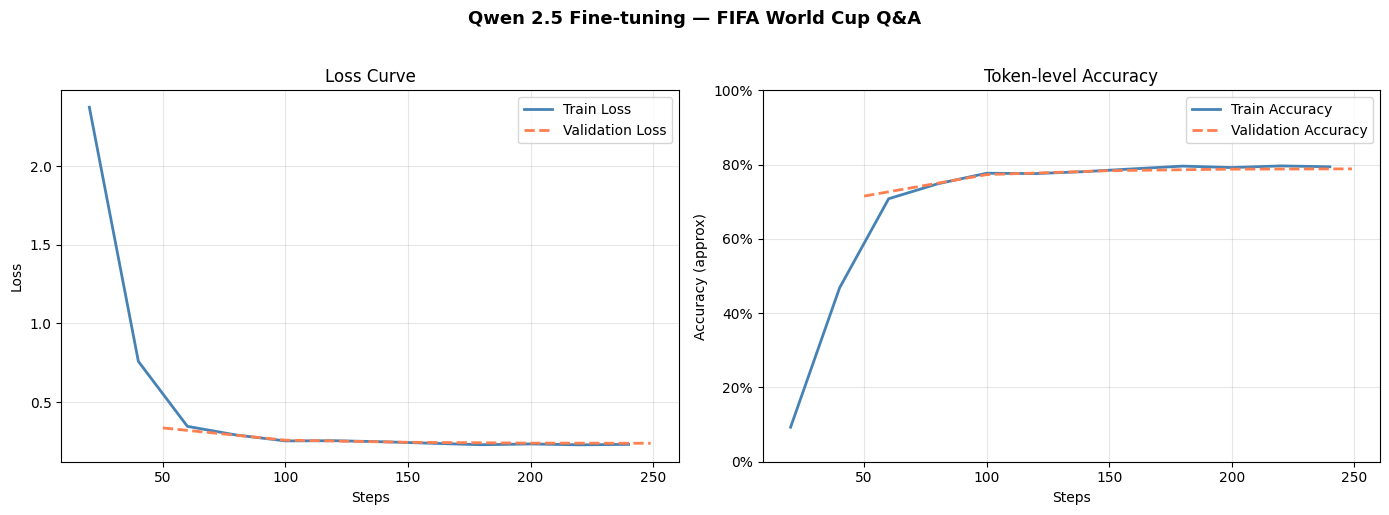

Plot saved!


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

log_history  = trainer.state.log_history
train_steps  = [x["step"] for x in log_history if "loss" in x and "eval_loss" not in x]
train_losses = [x["loss"] for x in log_history if "loss" in x and "eval_loss" not in x]
val_steps    = [x["step"] for x in log_history if "eval_loss" in x]
val_losses   = [x["eval_loss"] for x in log_history if "eval_loss" in x]

train_acc = [min(np.exp(-l), 1.0) for l in train_losses]
val_acc   = [min(np.exp(-l), 1.0) for l in val_losses]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_steps, train_losses, label="Train Loss",      color="steelblue", linewidth=2)
axes[0].plot(val_steps,   val_losses,   label="Validation Loss", color="coral",     linewidth=2, linestyle="--")
axes[0].set_xlabel("Steps"); axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curve"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(train_steps, train_acc, label="Train Accuracy",      color="steelblue", linewidth=2)
axes[1].plot(val_steps,   val_acc,   label="Validation Accuracy", color="coral",     linewidth=2, linestyle="--")
axes[1].set_xlabel("Steps"); axes[1].set_ylabel("Accuracy (approx)")
axes[1].set_title("Token-level Accuracy"); axes[1].set_ylim(0, 1)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y*100:.0f}%"))
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle("Qwen 2.5 Fine-tuning — FIFA World Cup Q&A", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_plots.png", bbox_inches="tight", dpi=150)
plt.show()
print("Plot saved!")

Evaluate

In [ ]:
import math

eval_results = trainer.evaluate()
perplexity   = math.exp(eval_results["eval_loss"])
print(f"Validation Loss : {eval_results['eval_loss']:.4f}")
print(f"Perplexity      : {perplexity:.2f}")

if   perplexity < 10:  print("Excellent — model fits the Q&A style very well.")
elif perplexity < 30:  print("Good — model has learned the domain reasonably well.")
else:                  print("Consider more epochs or a lower learning rate.")


model.eval()

test_questions = [
    "Who won the 1970 FIFA World Cup?",
    "Which country has won the most FIFA World Cups?",
    "Who was the runner-up at the 2014 FIFA World Cup?",
]

for question in test_questions:
    prompt = (
        f"<|system|>You are a FIFA World Cup expert assistant.</s>\n"
        f"<|user|>{question}</s>\n"
        f"<|assistant|>"
    )
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=80,
            temperature=0.3,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
        )
    answer = tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    print(f"\nQ: {question}")
    print(f"A: {answer.strip()}")

Training Loss,Validation Loss,Step,Entropy,Mean Token Accuracy,Num Tokens
0.230482,0.237518,249,0.243087,0.918806,305139.000000


Validation Loss : 0.2375
Perplexity      : 1.27
Excellent — model fits the Q&A style very well.

Q: Who won the 1970 FIFA World Cup?
A: Brazil won the 1970 FIFA World Cup, which was hosted by Spain.</s>

Q: Which country has won the most FIFA World Cups?
A: France has won the most FIFA World Cups with 10 titles.</s>

Q: Who was the runner-up at the 2014 FIFA World Cup?
A: The runner-up at the 2014 FIFA World Cup was Germany FR.</s>
